# Athletics Jump — Competition Competitiveness Analysis

This notebook analyzes the competitiveness of the four athletics jumping disciplines between 2016 and 2025:

- Long Jump
- Triple Jump
- High Jump
- Pole Vault

The objective is to identify competitions combining:

1. A strong international field.
2. A high concentration of world-ranked athletes.
3. A small performance gap between the leading athletes.

The analysis will ultimately classify competitions according to their competitive profile and identify the disciplines and periods offering the strongest combination of elite level and competitive closeness.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plotting style
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

# Project paths
PROJECT_DIR = Path(
    r"C:\Users\USER\Olympics\disciplines\3-athletics-jump"
)

TOPLIST_PATH = (
    PROJECT_DIR
    / "data"
    / "processed"
    / "world_athletics_toplists_2016_2025.csv"
)

RESULTS_PATH = (
    PROJECT_DIR
    / "data"
    / "jump_results.csv"
)

# Load source datasets
toplists = pd.read_csv(TOPLIST_PATH)
results = pd.read_csv(RESULTS_PATH)

# 2. Data Cleaning & Harmonization

The raw competition results and World Athletics top lists use different
formats for dates, genders, disciplines and performance values.

This step standardizes both datasets so they can be reliably combined later.

The cleaning process includes:

- removing competition results without a numeric performance;
- removing duplicate athlete performances within the same competition;
- converting competition dates to datetime;
- extracting the competition year;
- standardizing gender labels to `M` and `W`;
- standardizing discipline names across both datasets;
- converting World Athletics marks to numeric values.

The resulting datasets are:

- `results_clean`: cleaned competition-level performances;
- `toplists_clean`: standardized annual World Athletics rankings.

In [2]:
# Clean competition results
results_clean = (
    results
    .loc[results["mark_numeric"].notna()]
    .drop_duplicates(
        subset=[
            "competition_id",
            "event",
            "athlete",
            "mark_numeric"
        ]
    )
    .copy()
)

# Standardize dates and extract competition year
results_clean["start_date"] = pd.to_datetime(
    results_clean["start_date"],
    errors="coerce"
)

results_clean["year"] = results_clean["start_date"].dt.year

# Standardize gender
results_clean["gender"] = (
    results_clean["event"]
    .str.extract(
        r"^(Men's|Women's)",
        expand=False
    )
    .map({
        "Men's": "M",
        "Women's": "W"
    })
)

# Standardize discipline names
results_clean["discipline"] = (
    results_clean["event"]
    .str.replace("Men's ", "", regex=False)
    .str.replace("Women's ", "", regex=False)
)

# Clean World Athletics top lists
toplists_clean = toplists.copy()

toplists_clean["discipline"] = (
    toplists_clean["discipline"]
    .map({
        "Saut en longueur": "Long Jump",
        "Triple saut": "Triple Jump",
        "Saut en hauteur": "High Jump",
        "Saut à la perche": "Pole Vault"
    })
)

toplists_clean["gender"] = (
    toplists_clean["gender"]
    .map({
        "Hommes": "M",
        "Femmes": "W"
    })
)

toplists_clean["mark_numeric"] = pd.to_numeric(
    toplists_clean["mark"],
    errors="coerce"
)

# 3. Competition-Level Metrics

We now build the core competition-level dataset.

For each competition, gender and discipline, we measure:

- the number of participating athletes;
- the best performance;
- the relative performance of each athlete compared with the winner;
- the performance gaps between the winner and the 2nd, 3rd, 5th and 10th-ranked athletes;
- the average performance level of the top five athletes.

These indicators capture the **competitive closeness** of each competition.

A high `competition_depth` means that the leading athletes perform at a
similar level.

A low `gap_1_2`, for example, means that the difference between the winner
and the runner-up is small.

These metrics will later be combined with the athletes' world rankings to
distinguish between:

- competitions with a strong elite field;
- competitions that are tightly contested;
- competitions combining both characteristics.

In [3]:
# Competition-level grouping
competition_group = [
    "year",
    "competition_id",
    "gender",
    "discipline"
]

# Rank performances within each competition
competition_results = (
    results_clean
    .sort_values(
        competition_group + ["mark_numeric"],
        ascending=[True, True, True, True, False]
    )
    .copy()
)

competition_results["competition_rank"] = (
    competition_results
    .groupby(competition_group)
    .cumcount()
    + 1
)

# Best performance in each competition
competition_results["competition_best_mark"] = (
    competition_results
    .groupby(competition_group)["mark_numeric"]
    .transform("max")
)

# Performance relative to the competition winner
competition_results["relative_performance"] = (
    competition_results["mark_numeric"]
    / competition_results["competition_best_mark"]
)

# Number of athletes per competition
competition_size = (
    competition_results
    .groupby(competition_group)
    .agg(
        n_athletes=("athlete", "nunique")
    )
    .reset_index()
)

# Performance of key ranking positions
ranked_marks = (
    competition_results[
        competition_results["competition_rank"].isin(
            [1, 2, 3, 5, 10]
        )
    ]
    .pivot(
        index=competition_group,
        columns="competition_rank",
        values="mark_numeric"
    )
    .reset_index()
)

ranked_marks.columns.name = None

ranked_marks = ranked_marks.rename(
    columns={
        1: "mark_1",
        2: "mark_2",
        3: "mark_3",
        5: "mark_5",
        10: "mark_10"
    }
)

# Relative performance gaps from the winner
for rank in [2, 3, 5, 10]:
    ranked_marks[f"gap_1_{rank}"] = (
        1
        - ranked_marks[f"mark_{rank}"]
        / ranked_marks["mark_1"]
    )

# Average relative performance of the top five athletes
competition_depth = (
    competition_results[
        competition_results["competition_rank"] <= 5
    ]
    .groupby(competition_group)
    .agg(
        competition_depth=(
            "relative_performance",
            "mean"
        )
    )
    .reset_index()
)

# Base competition table
competition_base = (
    results_clean[
        [
            "year",
            "competition_id",
            "competition_name",
            "gender",
            "discipline"
        ]
    ]
    .drop_duplicates()
)

# Combine all competition-level metrics
competition_metrics = (
    competition_base
    .merge(
        competition_size,
        on=competition_group,
        how="left"
    )
    .merge(
        competition_depth,
        on=competition_group,
        how="left"
    )
    .merge(
        ranked_marks[
            competition_group
            + [
                "gap_1_2",
                "gap_1_3",
                "gap_1_5",
                "gap_1_10"
            ]
        ],
        on=competition_group,
        how="left"
    )
)

# 4. World Ranking Exposure

Competition depth tells us how close the performances are to each other,
but it does not tell us whether the athletes are actually world-class.

We therefore add the annual World Athletics ranking of each athlete to the
competition results.

For each competition, we measure:

- the number of athletes with a World Athletics ranking;
- the share of athletes ranked in the World Top 10;
- the share ranked in the World Top 25;
- the share ranked in the World Top 50;
- the average world ranking of the field;
- the median world ranking;
- the best world ranking present in the competition.

These indicators measure the **international strength of the field**.

The key distinction is:

- **Competition depth** = how close the performances are;
- **World level** = how strong the athletes are relative to the international field.

This distinction will allow us to identify competitions that are both
high-level and tightly contested.

In [4]:
# Annual World Athletics ranking for each athlete
athlete_world_rank = (
    toplists_clean[
        [
            "year",
            "gender",
            "discipline",
            "competitor",
            "rank"
        ]
    ]
    .drop_duplicates(
        subset=[
            "year",
            "gender",
            "discipline",
            "competitor"
        ]
    )
    .rename(
        columns={
            "competitor": "athlete",
            "rank": "world_rank"
        }
    )
)

# Add world ranking information to competition results
results_with_world_rank = results_clean.merge(
    athlete_world_rank,
    on=[
        "year",
        "gender",
        "discipline",
        "athlete"
    ],
    how="left"
)

# Competition-level world ranking indicators
competition_world = (
    results_with_world_rank
    .groupby(competition_group)
    .agg(
        n_athletes=("athlete", "nunique"),
        n_ranked_athletes=("world_rank", "count"),
        n_top10=(
            "world_rank",
            lambda x: (x <= 10).sum()
        ),
        n_top25=(
            "world_rank",
            lambda x: (x <= 25).sum()
        ),
        n_top50=(
            "world_rank",
            lambda x: (x <= 50).sum()
        ),
        mean_world_rank=("world_rank", "mean"),
        median_world_rank=("world_rank", "median"),
        best_world_rank=("world_rank", "min")
    )
    .reset_index()
)

# Share of ranked athletes belonging to the main world-ranking tiers
competition_world["share_top10"] = (
    competition_world["n_top10"]
    / competition_world["n_ranked_athletes"]
)

competition_world["share_top25"] = (
    competition_world["n_top25"]
    / competition_world["n_ranked_athletes"]
)

competition_world["share_top50"] = (
    competition_world["n_top50"]
    / competition_world["n_ranked_athletes"]
)

# 5. Competition Competitiveness Dataset

We now combine the two main dimensions of competitiveness:

- **Competitive depth**: how close the leading performances are.
- **World-level strength**: how strongly the competition is represented by
  internationally ranked athletes.

The resulting `competition_final` dataset is the central analytical table
used for the rest of the notebook.

We also aggregate the results by gender and discipline to identify the main
structural differences between events.

### Business objective

At this stage, we want to answer a first simple question:

> Which disciplines consistently attract strong international fields, and
> which disciplines produce the tightest competitions?

These descriptive results provide the business context before applying
dimensionality reduction and clustering.

In [5]:
# Combine performance-based and world-ranking-based metrics
competition_final = (
    competition_metrics
    .merge(
        competition_world,
        on=competition_group,
        how="left",
        suffixes=("", "_world")
    )
)

# Main analytical features
analysis_features = [
    "competition_depth",
    "share_top10",
    "share_top25",
    "share_top50",
    "gap_1_2",
    "gap_1_3",
    "gap_1_5",
    "gap_1_10",
    "mean_world_rank",
    "median_world_rank",
    "best_world_rank"
]

# Overall descriptive summary by gender and discipline
discipline_summary = (
    competition_final
    .groupby(["gender", "discipline"])
    .agg(
        n_competitions=("competition_id", "nunique"),
        mean_depth=("competition_depth", "mean"),
        mean_top10=("share_top10", "mean"),
        mean_top25=("share_top25", "mean"),
        mean_top50=("share_top50", "mean"),
        mean_gap_1_2=("gap_1_2", "mean"),
        mean_gap_1_5=("gap_1_5", "mean"),
        mean_world_rank=("mean_world_rank", "mean")
    )
    .reset_index()
)

discipline_summary

,gender,discipline,n_competitions,mean_depth,mean_top10,mean_top25,mean_top50,mean_gap_1_2,mean_gap_1_5,mean_world_rank
0,M,High Jump,59,0.981354,0.499418,0.759561,0.910797,0.009550,0.036603,23.915011
1,M,Long Jump,49,0.978054,0.458101,0.695159,0.862141,0.013159,0.042052,25.800748
2,M,Pole Vault,73,0.968547,0.637265,0.889090,0.974537,0.024620,0.052527,11.813429
3,M,Triple Jump,44,0.978076,0.510993,0.851322,0.960506,0.010896,0.043232,15.899655
4,W,High Jump,63,0.976093,0.540594,0.853934,0.964783,0.014555,0.042960,14.889389
5,W,Long Jump,53,0.975153,0.439022,0.714574,0.872372,0.016741,0.044238,26.946102
6,W,Pole Vault,66,0.976752,0.616979,0.904030,0.980381,0.013931,0.043320,11.921905
7,W,Triple Jump,44,0.977121,0.643016,0.940540,0.979048,0.015449,0.041649,10.498795


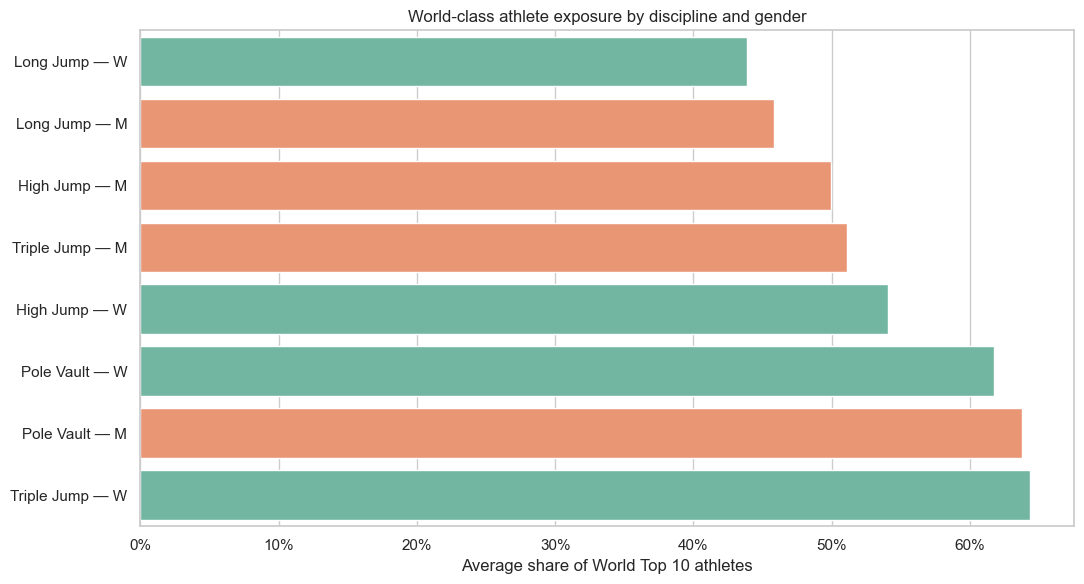

In [6]:
# World-class athlete exposure by discipline
plot_data = discipline_summary.copy()

plot_data["group"] = (
    plot_data["discipline"]
    + " — "
    + plot_data["gender"]
)

plot_data = plot_data.sort_values("mean_top10")

plt.figure(figsize=(11, 6))

sns.barplot(
    data=plot_data,
    x="mean_top10",
    y="group",
    hue="gender",
    dodge=False,
    legend=False,
    palette="Set2"
)

plt.gca().xaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1.0)
)

plt.xlabel("Average share of World Top 10 athletes")
plt.ylabel("")
plt.title(
    "World-class athlete exposure by discipline and gender"
)

plt.tight_layout()
plt.show()

The descriptive analysis shows that the disciplines differ substantially
in their ability to attract world-class athletes.

The share of World Top 10 athletes provides a direct measure of elite
exposure, while competition depth measures how tightly these athletes
compete against each other.

This suggests that the most attractive competitive profiles should not be
identified using world ranking alone: a strong field is not necessarily a
close competition.

# 6. Exploratory Analysis — Competition Profiles

Before applying PCA or clustering, we examine the relationship between
international field strength and competitive closeness.

The key question is:

> Do competitions with a stronger concentration of world-class athletes
> also tend to be more tightly contested?

We use two complementary indicators:

- `share_top10`: share of ranked athletes belonging to the World Top 10;
- `competition_depth`: average performance of the top five athletes relative
  to the winner.

A high `share_top10` indicates a strong international field.

A high `competition_depth` indicates a closely contested competition.

### Business interpretation

The most strategically interesting competitions are those combining
both characteristics:

**strong international level + strong competitive closeness.**

This analysis also helps determine whether these two dimensions capture
different aspects of competition quality and therefore justify a
multidimensional approach.

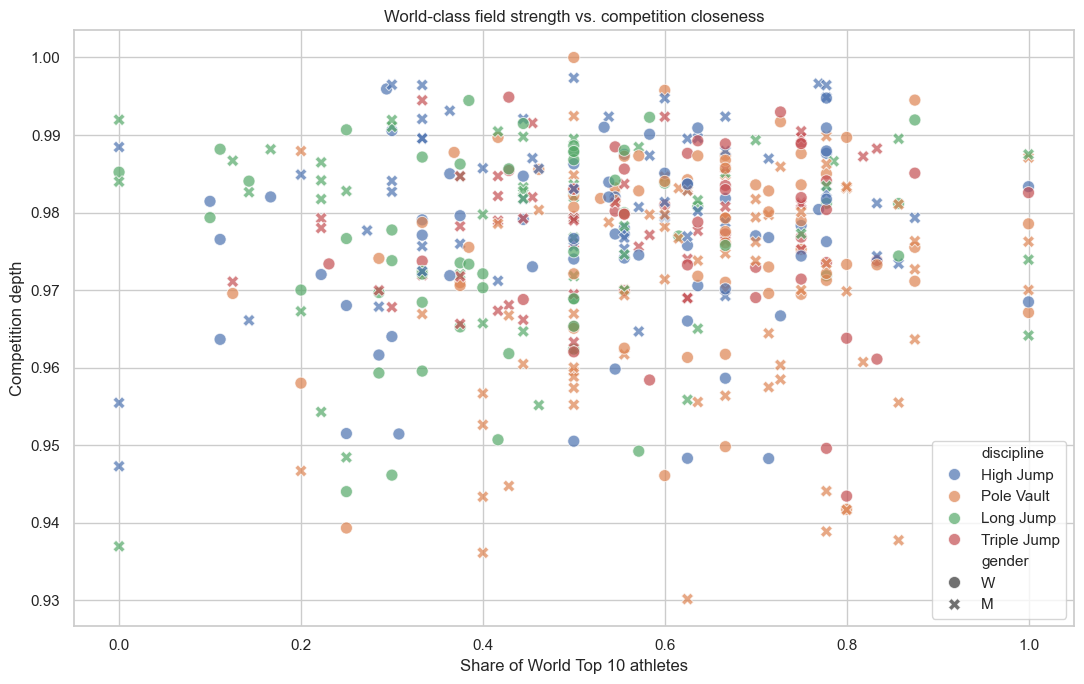

In [7]:
# Competition-level relationship between world-class exposure and depth
plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=competition_final,
    x="share_top10",
    y="competition_depth",
    hue="discipline",
    style="gender",
    s=75,
    alpha=0.70
)

plt.xlabel("Share of World Top 10 athletes")
plt.ylabel("Competition depth")
plt.title(
    "World-class field strength vs. competition closeness"
)

plt.tight_layout()
plt.show()

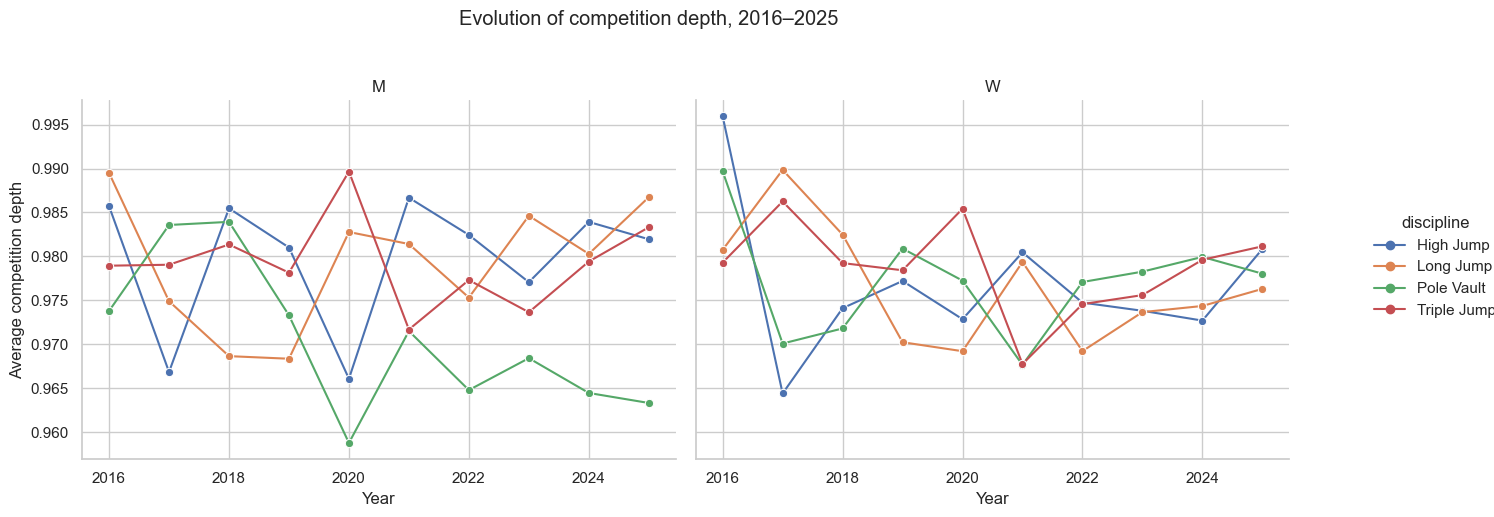

In [12]:
# Evolution of competition depth over time
yearly_depth = (
    competition_final
    .groupby(
        ["year", "gender", "discipline"]
    )
    .agg(
        competition_depth=("competition_depth", "mean"),
        share_top10=("share_top10", "mean")
    )
    .reset_index()
)

g = sns.relplot(
    data=yearly_depth,
    x="year",
    y="competition_depth",
    hue="discipline",
    col="gender",
    kind="line",
    marker="o",
    height=5,
    aspect=1.2,
    legend="full"
)

g.set_axis_labels(
    "Year",
    "Average competition depth"
)

g.set_titles("{col_name}")

g.fig.suptitle(
    "Evolution of competition depth, 2016–2025",
    y=1.03
)

g._legend.set_bbox_to_anchor((1.02, 0.5))
g._legend.set_loc("center left")

g.fig.subplots_adjust(
    right=0.98,
    top=0.85
)

plt.show()

The analysis separates two dimensions of competition quality:

- **International strength** reflects the concentration of highly ranked
  athletes in the field.
- **Competitive closeness** reflects how tightly the leading athletes
  compete against each other.

These dimensions should therefore not be reduced to a single raw metric.

A competition can attract many world-class athletes without being especially
close, while another competition can be highly contested despite having a
less prestigious field.

The next step is therefore to combine these correlated indicators into
robust composite dimensions using PCA.

# 7. PCA — World Level and Competition Closeness

Several indicators measure similar underlying concepts.

For example, `share_top10`, `share_top25` and `share_top50` all measure
international field strength. Similarly, `competition_depth` and the
performance gaps between leading athletes all describe competitive
closeness.

Principal Component Analysis (PCA) is used to reduce these correlated
variables into two interpretable composite dimensions:

1. **World Level Score**
   - summarizes the international strength of the field;
   - higher values indicate a stronger concentration of highly ranked
     athletes.

2. **Closeness Score**
   - summarizes how tightly the leading athletes compete;
   - higher values indicate smaller performance gaps and a more competitive
     field.

All variables are standardized before PCA so that differences in scale do
not influence the results.

The direction of each PCA score is explicitly aligned with the business
interpretation: **higher score = stronger competitive profile**.

In [13]:
# World-level indicators
world_level_features = [
    "share_top10",
    "share_top25",
    "share_top50",
    "mean_world_rank",
    "median_world_rank",
    "best_world_rank"
]

world_level_data = (
    competition_final
    .dropna(subset=world_level_features)
    .copy()
)

# Standardize the indicators
world_level_scaler = StandardScaler()

X_world_level = world_level_scaler.fit_transform(
    world_level_data[world_level_features]
)

# PCA
world_level_pca = PCA()

X_world_level_pca = world_level_pca.fit_transform(
    X_world_level
)

# Explained variance
world_level_variance = pd.DataFrame({
    "component": np.arange(
        1,
        len(world_level_features) + 1
    ),
    "explained_variance": (
        world_level_pca.explained_variance_ratio_
    )
})

world_level_variance["cumulative_variance"] = (
    world_level_variance["explained_variance"]
    .cumsum()
)

display(
    world_level_variance.round(3)
)

# PCA loadings
world_level_loadings = pd.DataFrame(
    world_level_pca.components_.T,
    index=world_level_features,
    columns=[
        f"PC{i}"
        for i in range(
            1,
            len(world_level_features) + 1
        )
    ]
)

display(
    world_level_loadings.round(3)
)

,component,explained_variance,cumulative_variance
0,1,0.721,0.721
1,2,0.156,0.877
2,3,0.069,0.946
3,4,0.030,0.976
4,5,0.017,0.993
5,6,0.007,1.000


,PC1,PC2,PC3,PC4,PC5,PC6
share_top10,-0.320,0.651,-0.575,-0.333,0.173,0.052
share_top25,-0.400,0.433,0.281,0.750,-0.025,0.103
share_top50,-0.425,-0.015,0.622,-0.485,0.309,0.318
mean_world_rank,0.469,0.119,-0.081,0.095,0.076,0.863
median_world_rank,0.446,0.252,0.180,0.096,0.763,-0.338
best_world_rank,0.372,0.557,0.405,-0.271,-0.535,-0.164


In [14]:
# Competition-closeness indicators
closeness_features = [
    "competition_depth",
    "gap_1_2",
    "gap_1_3",
    "gap_1_5"
]

closeness_data = (
    competition_final
    .dropna(subset=closeness_features)
    .copy()
)

# Standardize the indicators
closeness_scaler = StandardScaler()

X_closeness = closeness_scaler.fit_transform(
    closeness_data[closeness_features]
)

# PCA
closeness_pca = PCA()

X_closeness_pca = closeness_pca.fit_transform(
    X_closeness
)

# Explained variance
closeness_variance = pd.DataFrame({
    "component": np.arange(
        1,
        len(closeness_features) + 1
    ),
    "explained_variance": (
        closeness_pca.explained_variance_ratio_
    )
})

closeness_variance["cumulative_variance"] = (
    closeness_variance["explained_variance"]
    .cumsum()
)

display(
    closeness_variance.round(3)
)

# PCA loadings
closeness_loadings = pd.DataFrame(
    closeness_pca.components_.T,
    index=closeness_features,
    columns=[
        f"PC{i}"
        for i in range(
            1,
            len(closeness_features) + 1
        )
    ]
)

display(
    closeness_loadings.round(3)
)

,component,explained_variance,cumulative_variance
0,1,0.853,0.853
1,2,0.096,0.950
2,3,0.047,0.997
3,4,0.003,1.000


,PC1,PC2,PC3,PC4
competition_depth,0.538,0.113,-0.016,0.835
gap_1_2,-0.472,0.714,-0.478,0.198
gap_1_3,-0.507,0.104,0.791,0.327
gap_1_5,-0.481,-0.683,-0.382,0.395


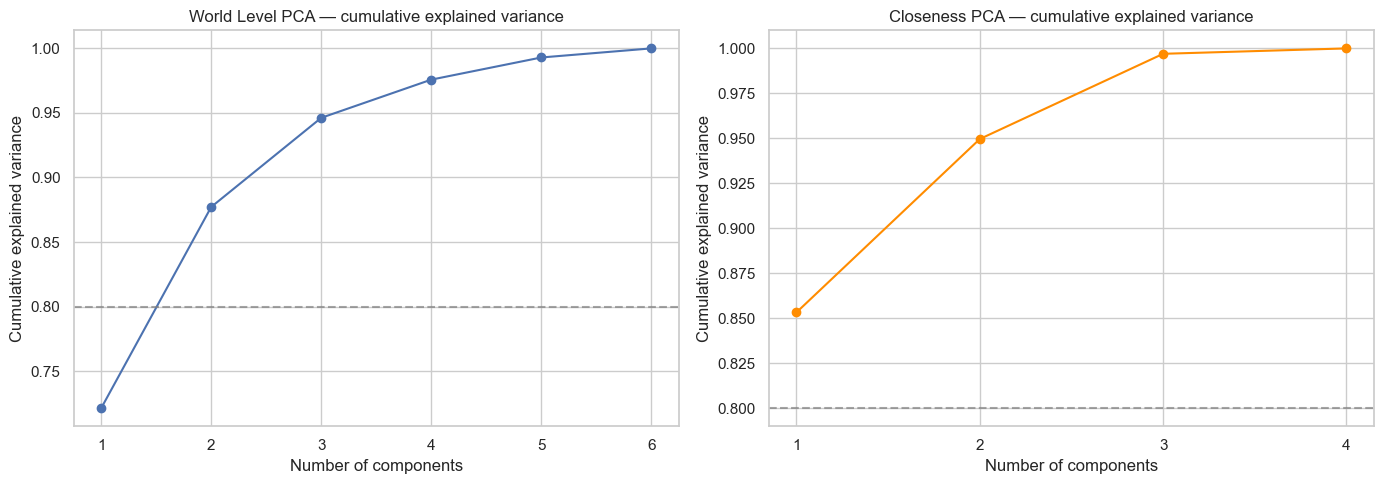

In [15]:
# Visualize cumulative explained variance
fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5)
)

# World level
axes[0].plot(
    world_level_variance["component"],
    world_level_variance["cumulative_variance"],
    marker="o"
)

axes[0].axhline(
    0.80,
    color="grey",
    linestyle="--",
    alpha=0.7
)

axes[0].set_title(
    "World Level PCA — cumulative explained variance"
)

axes[0].set_xlabel("Number of components")
axes[0].set_ylabel("Cumulative explained variance")

axes[0].set_xticks(
    world_level_variance["component"]
)

# Closeness
axes[1].plot(
    closeness_variance["component"],
    closeness_variance["cumulative_variance"],
    marker="o",
    color="darkorange"
)

axes[1].axhline(
    0.80,
    color="grey",
    linestyle="--",
    alpha=0.7
)

axes[1].set_title(
    "Closeness PCA — cumulative explained variance"
)

axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Cumulative explained variance")

axes[1].set_xticks(
    closeness_variance["component"]
)

plt.tight_layout()
plt.show()

In [16]:
# ------------------------------------------------------------
# World Level Score
# ------------------------------------------------------------

world_level_data["world_level_score"] = (
    X_world_level_pca[:, 0]
)

# Higher world rank = weaker athlete.
# Reverse the score if necessary so that a higher score always
# represents a stronger international field.
world_level_rank_correlation = (
    world_level_data[
        [
            "world_level_score",
            "mean_world_rank"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

if world_level_rank_correlation > 0:
    world_level_data["world_level_score"] *= -1


# ------------------------------------------------------------
# Competition Closeness Score
# ------------------------------------------------------------

closeness_data["closeness_score"] = (
    X_closeness_pca[:, 0]
)

# A high performance gap means a less competitive field.
# Reverse the score if necessary so that a higher score always
# represents a tighter competition.
closeness_gap_correlation = (
    closeness_data[
        [
            "closeness_score",
            "gap_1_2"
        ]
    ]
    .corr()
    .iloc[0, 1]
)

if closeness_gap_correlation > 0:
    closeness_data["closeness_score"] *= -1

The PCA transforms several overlapping indicators into two synthetic
dimensions:

- **World Level Score** represents the overall international strength of
  the competition field.
- **Closeness Score** represents the degree to which the leading athletes
  compete at a similar performance level.

The scores are oriented so that higher values always represent a more
favorable competitive profile.

This gives us a much cleaner analytical framework than comparing a large
number of individual indicators.

The next step is to combine these two dimensions into a single competition
map, where each competition can be positioned according to its:

- international level;
- competitive closeness.

This will allow us to identify the most attractive competition profiles
before moving to clustering.

# 8. Competition Positioning Map

We now combine the two PCA dimensions into a single strategic map.

Each point represents one competition:

- X-axis: **World Level Score**
- Y-axis: **Closeness Score**

The four quadrants provide a simple business interpretation:

| Profile | Interpretation |
|---|---|
| High level + high closeness | **Elite & Competitive** |
| High level + low closeness | Elite field, but less contested |
| Low level + high closeness | Competitive field without the strongest elite presence |
| Low level + low closeness | Lower international level and less competitive |

The most strategically interesting quadrant is therefore:

**High World Level + High Closeness**

These competitions combine a strong international field with a high degree
of competitive tension.

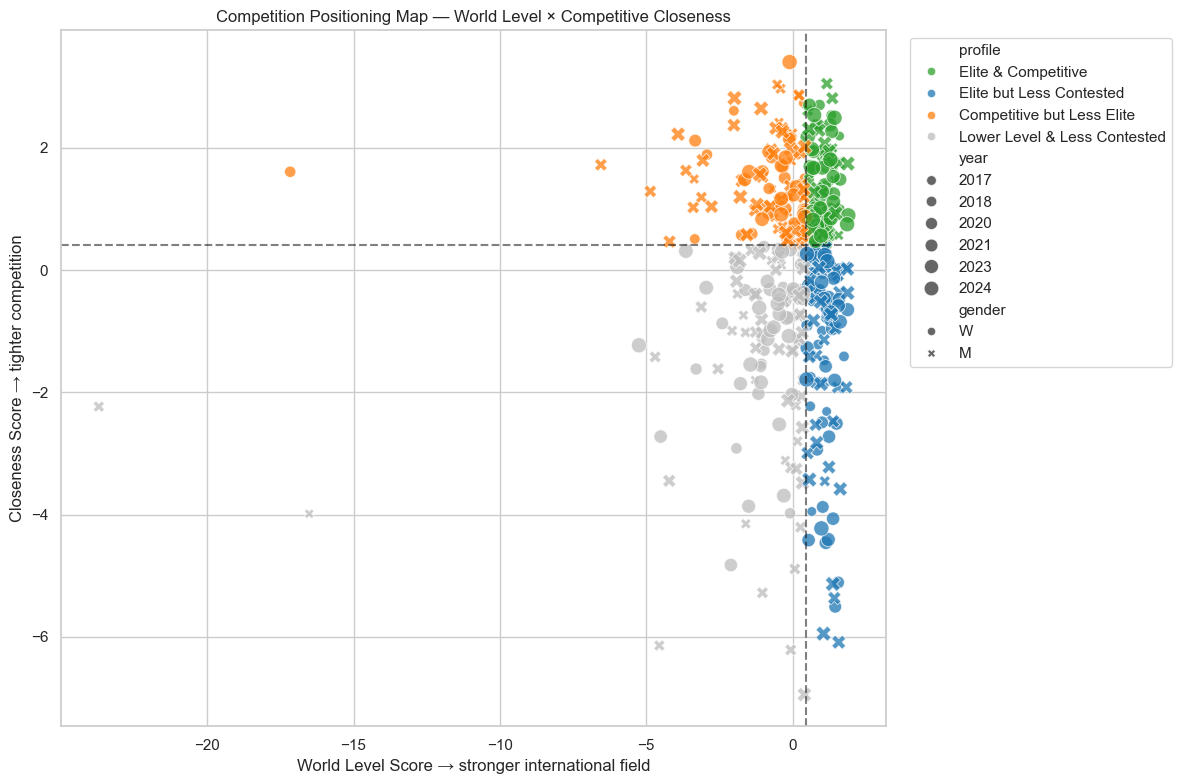

In [17]:
# Combine the two PCA scores at competition level
competition_scores = (
    world_level_data[
        [
            "year",
            "competition_id",
            "gender",
            "discipline",
            "world_level_score"
        ]
    ]
    .merge(
        closeness_data[
            [
                "year",
                "competition_id",
                "gender",
                "discipline",
                "closeness_score"
            ]
        ],
        on=[
            "year",
            "competition_id",
            "gender",
            "discipline"
        ],
        how="inner"
    )
)

# Median-based thresholds define the four strategic quadrants
world_level_median = (
    competition_scores["world_level_score"].median()
)

closeness_median = (
    competition_scores["closeness_score"].median()
)

competition_scores["profile"] = np.select(
    [
        (
            (competition_scores["world_level_score"] >= world_level_median)
            & (competition_scores["closeness_score"] >= closeness_median)
        ),
        (
            (competition_scores["world_level_score"] >= world_level_median)
            & (competition_scores["closeness_score"] < closeness_median)
        ),
        (
            (competition_scores["world_level_score"] < world_level_median)
            & (competition_scores["closeness_score"] >= closeness_median)
        )
    ],
    [
        "Elite & Competitive",
        "Elite but Less Contested",
        "Competitive but Less Elite"
    ],
    default="Lower Level & Less Contested"
)

# Strategic positioning map
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=competition_scores,
    x="world_level_score",
    y="closeness_score",
    hue="profile",
    style="gender",
    size="year",
    sizes=(40, 120),
    alpha=0.75,
    palette={
        "Elite & Competitive": "#2ca02c",
        "Elite but Less Contested": "#1f77b4",
        "Competitive but Less Elite": "#ff7f0e",
        "Lower Level & Less Contested": "#bdbdbd"
    }
)

plt.axvline(
    world_level_median,
    color="black",
    linestyle="--",
    alpha=0.5
)

plt.axhline(
    closeness_median,
    color="black",
    linestyle="--",
    alpha=0.5
)

plt.xlabel(
    "World Level Score → stronger international field"
)

plt.ylabel(
    "Closeness Score → tighter competition"
)

plt.title(
    "Competition Positioning Map — World Level × Competitive Closeness"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [18]:
# Summary of competition profiles
profile_summary = (
    competition_scores
    .groupby("profile")
    .agg(
        n_competitions=("competition_id", "nunique"),
        share=("competition_id", "count"),
        mean_world_level=("world_level_score", "mean"),
        mean_closeness=("closeness_score", "mean")
    )
    .reset_index()
)

profile_summary["share"] = (
    profile_summary["share"]
    / len(competition_scores)
)

profile_summary = profile_summary.sort_values(
    "mean_world_level",
    ascending=False
)

display(
    profile_summary.round(3)
)

,profile,n_competitions,share,mean_world_level,mean_closeness
2,Elite but Less Contested,66,0.25,1.103,-1.304
1,Elite & Competitive,63,0.25,1.031,1.352
0,Competitive but Less Elite,78,0.25,-0.895,1.407
3,Lower Level & Less Contested,76,0.25,-1.234,-1.383


In [19]:
# Identify the strongest "Elite & Competitive" competitions
elite_competitions = (
    competition_scores[
        competition_scores["profile"]
        == "Elite & Competitive"
    ]
    .sort_values(
        [
            "world_level_score",
            "closeness_score"
        ],
        ascending=False
    )
)

display(
    elite_competitions.head(20)
)

,year,competition_id,gender,discipline,world_level_score,closeness_score,profile
398,2025,7199686,W,High Jump,1.899801,0.896579,Elite & Competitive
404,2025,7199686,M,Long Jump,1.878749,1.744150,Elite & Competitive
401,2025,7199686,W,Triple Jump,1.858862,0.752228,Elite & Competitive
255,2022,7153971,W,Triple Jump,1.620959,1.484589,Elite & Competitive
42,2018,7120542,W,Long Jump,1.604351,1.002631,Elite & Competitive
31,2017,7104903,W,Long Jump,1.602013,2.194553,Elite & Competitive
274,2022,7153975,M,Triple Jump,1.578192,1.754269,Elite & Competitive
44,2018,7120542,M,Pole Vault,1.573036,0.570817,Elite & Competitive
439,2025,7203944,M,Long Jump,1.467407,0.930995,Elite & Competitive
50,2018,7120996,W,Pole Vault,1.448718,1.782406,Elite & Competitive


The positioning map separates competition quality into two independent
dimensions.

The **Elite & Competitive** quadrant is the priority profile because it
combines:

- a strong concentration of internationally ranked athletes;
- a high level of competitive closeness.

This profile is more strategically attractive than simply maximizing the
number of world-class athletes.

The map also highlights an important distinction between:

- competitions that attract elite athletes but produce relatively clear
  outcomes;
- competitions where athletes are closely matched but the overall
  international level is lower.

The next step is to move from this continuous positioning to a small number
of clearly defined competition segments using clustering.

# 9. Competition Segmentation — K-Means

The positioning map provides a continuous view of competition profiles.

We now convert this continuous space into a small number of homogeneous
competition segments using K-Means clustering.

The clustering is based only on the two strategic dimensions identified by
the PCA:

- `world_level_score`
- `closeness_score`

We use **three clusters** to obtain a simple and business-oriented
segmentation.

The objective is not to create arbitrary statistical groups, but to identify
clear competitive profiles that can be compared across disciplines and
genders.

The resulting clusters will be interpreted according to their average:

- international level;
- competitive closeness;
- overall competitive profile.

In [20]:
# Standardize the two strategic dimensions
cluster_features = [
    "world_level_score",
    "closeness_score"
]

cluster_scaler = StandardScaler()

X_cluster = cluster_scaler.fit_transform(
    competition_scores[cluster_features]
)

# Three-cluster solution
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=50
)

competition_scores["cluster"] = (
    kmeans.fit_predict(X_cluster)
)

# Cluster centers in the original score scale
cluster_centers = pd.DataFrame(
    cluster_scaler.inverse_transform(
        kmeans.cluster_centers_
    ),
    columns=cluster_features
)

cluster_centers.index.name = "cluster"

display(
    cluster_centers.round(3)
)

,world_level_score,closeness_score
cluster,,
0,0.206,0.820
1,-0.116,-2.635
2,-19.125,-1.536


In [21]:
# Rank clusters by their overall competitive position
cluster_centers["overall_position"] = (
    cluster_centers["world_level_score"]
    + cluster_centers["closeness_score"]
)

cluster_order = (
    cluster_centers["overall_position"]
    .sort_values(ascending=False)
    .index
)

# Assign business labels according to the cluster profiles
cluster_labels = {}

highest_cluster = cluster_order[0]
lowest_cluster = cluster_order[-1]
middle_cluster = cluster_order[1]

cluster_labels[highest_cluster] = (
    "Elite & Competitive"
)

cluster_labels[lowest_cluster] = (
    "Lower Level & Less Contested"
)

# The remaining cluster represents the intermediate profile
middle_world_level = cluster_centers.loc[
    middle_cluster,
    "world_level_score"
]

middle_closeness = cluster_centers.loc[
    middle_cluster,
    "closeness_score"
]

if middle_world_level >= middle_closeness:
    cluster_labels[middle_cluster] = (
        "Elite but Less Contested"
    )
else:
    cluster_labels[middle_cluster] = (
        "Competitive but Less Elite"
    )

competition_scores["segment"] = (
    competition_scores["cluster"]
    .map(cluster_labels)
)

# Final cluster profile
segment_profile = (
    competition_scores
    .groupby("segment")
    .agg(
        n_competitions=("competition_id", "nunique"),
        mean_world_level=("world_level_score", "mean"),
        mean_closeness=("closeness_score", "mean")
    )
    .reset_index()
)

segment_profile["share"] = (
    segment_profile["n_competitions"]
    / segment_profile["n_competitions"].sum()
)

segment_profile = segment_profile.sort_values(
    "mean_world_level",
    ascending=False
)

display(
    segment_profile.round(3)
)

,segment,n_competitions,mean_world_level,mean_closeness,share
0,Elite & Competitive,107,0.206,0.820,0.591
1,Elite but Less Contested,72,-0.116,-2.635,0.398
2,Lower Level & Less Contested,2,-19.125,-1.536,0.011


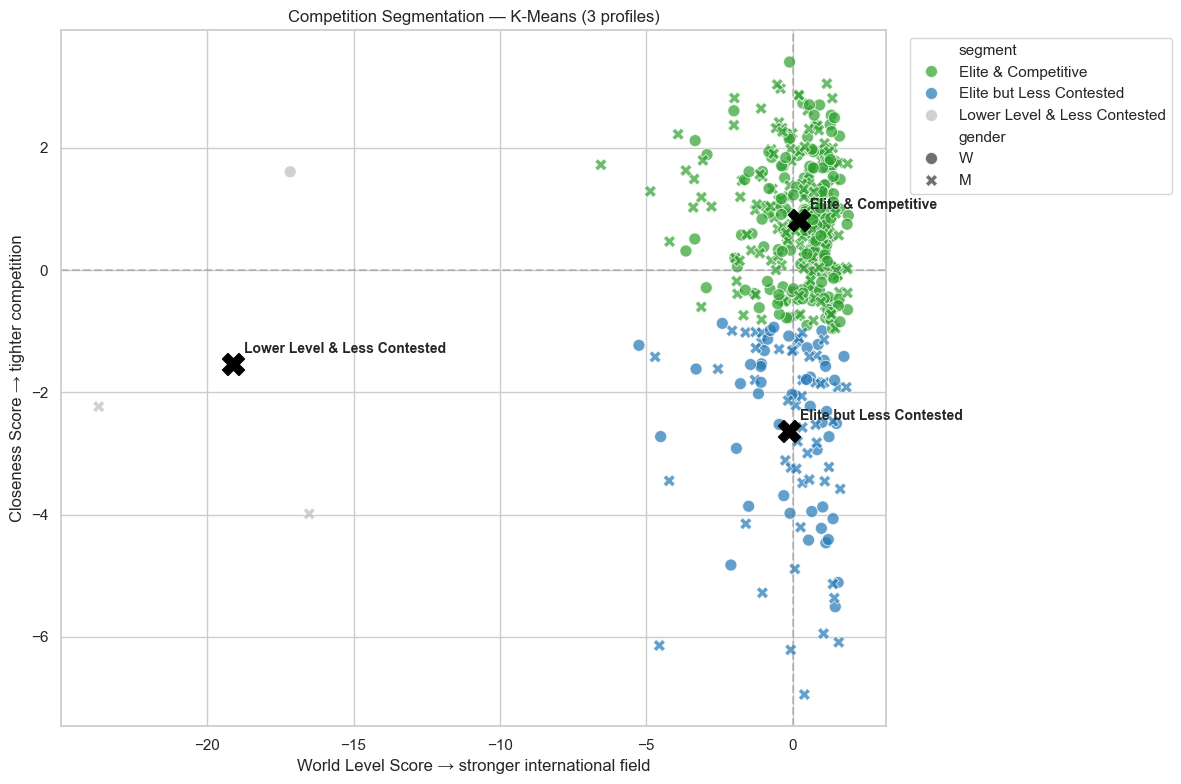

In [22]:
# Visualize the final competition segments
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=competition_scores,
    x="world_level_score",
    y="closeness_score",
    hue="segment",
    style="gender",
    s=75,
    alpha=0.70,
    palette={
        "Elite & Competitive": "#2ca02c",
        "Elite but Less Contested": "#1f77b4",
        "Lower Level & Less Contested": "#bdbdbd"
    }
)

# Plot cluster centers
for cluster_id, label in cluster_labels.items():
    center = cluster_centers.loc[cluster_id]

    plt.scatter(
        center["world_level_score"],
        center["closeness_score"],
        color="black",
        marker="X",
        s=250,
        zorder=5
    )

    plt.annotate(
        label,
        (
            center["world_level_score"],
            center["closeness_score"]
        ),
        xytext=(8, 8),
        textcoords="offset points",
        fontsize=10,
        fontweight="bold"
    )

plt.axvline(
    0,
    color="grey",
    linestyle="--",
    alpha=0.4
)

plt.axhline(
    0,
    color="grey",
    linestyle="--",
    alpha=0.4
)

plt.xlabel(
    "World Level Score → stronger international field"
)

plt.ylabel(
    "Closeness Score → tighter competition"
)

plt.title(
    "Competition Segmentation — K-Means (3 profiles)"
)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

In [23]:
# Distribution of competition segments by gender and discipline
segment_distribution = (
    competition_scores
    .groupby(
        [
            "gender",
            "discipline",
            "segment"
        ]
    )
    .size()
    .reset_index(
        name="n_competitions"
    )
)

segment_distribution["share"] = (
    segment_distribution
    .groupby(
        [
            "gender",
            "discipline"
        ]
    )["n_competitions"]
    .transform(
        lambda x: x / x.sum()
    )
)

display(
    segment_distribution
    .sort_values(
        [
            "gender",
            "discipline",
            "share"
        ],
        ascending=[True, True, False]
    )
)

,gender,discipline,segment,n_competitions,share
0,M,High Jump,Elite & Competitive,51,0.910714
1,M,High Jump,Elite but Less Contested,3,0.053571
2,M,High Jump,Lower Level & Less Contested,2,0.035714
3,M,Long Jump,Elite & Competitive,39,0.795918
4,M,Long Jump,Elite but Less Contested,10,0.204082
5,M,Pole Vault,Elite & Competitive,40,0.563380
6,M,Pole Vault,Elite but Less Contested,31,0.436620
7,M,Triple Jump,Elite & Competitive,34,0.809524
8,M,Triple Jump,Elite but Less Contested,8,0.190476
9,W,High Jump,Elite & Competitive,48,0.761905


The K-Means segmentation transforms the continuous competition map into
three interpretable competitive profiles.

The most strategically valuable segment is **Elite & Competitive**:

- strong international representation;
- high competitive closeness;
- therefore, a strong combination of sporting quality and competitive
  tension.

The other segments represent different strategic situations:

- **Elite but Less Contested**: strong international participation, but
  larger performance differences between the leading athletes.
- **Lower Level & Less Contested**: lower international strength combined
  with weaker competitive closeness.

The distribution of these segments across disciplines and genders is the
key output for identifying where the strongest competition profiles are
structurally concentrated.

# 10. Final Business Conclusions

The final step translates the competition analysis into actionable business
insights.

We focus on four questions:

1. Which disciplines have the strongest overall competitive profile?
2. Which disciplines generate the highest share of **Elite & Competitive**
   competitions?
3. How has the competitive profile evolved over time?
4. Which competitions represent the strongest examples of the target
   profile?

The analysis distinguishes between:

- **World-level strength**: presence of internationally ranked athletes;
- **Competitive closeness**: proximity between leading performances;
- **Elite & Competitive profile**: combination of both dimensions.

The final outputs provide a concise view of where the strongest competition
is structurally concentrated and which individual competitions best
illustrate this profile.

In [24]:
# Overall competitive profile by gender and discipline
final_discipline_summary = (
    competition_scores
    .groupby(
        ["gender", "discipline"]
    )
    .agg(
        n_competitions=("competition_id", "nunique"),
        mean_world_level=("world_level_score", "mean"),
        mean_closeness=("closeness_score", "mean"),
        share_elite_competitive=(
            "segment",
            lambda x: (
                x == "Elite & Competitive"
            ).mean()
        )
    )
    .reset_index()
)

# Combined score used only for ranking the final summary
final_discipline_summary["overall_score"] = (
    final_discipline_summary["mean_world_level"]
    + final_discipline_summary["mean_closeness"]
)

final_discipline_summary = (
    final_discipline_summary
    .sort_values(
        [
            "gender",
            "overall_score"
        ],
        ascending=[True, False]
    )
)

display(
    final_discipline_summary.round(3)
)

,gender,discipline,n_competitions,mean_world_level,mean_closeness,share_elite_competitive,overall_score
3,M,Triple Jump,42,0.103,0.313,0.810,0.416
0,M,High Jump,56,-0.830,0.897,0.911,0.067
2,M,Pole Vault,71,0.686,-1.180,0.563,-0.493
1,M,Long Jump,49,-1.015,0.274,0.796,-0.741
7,W,Triple Jump,44,0.843,0.090,0.795,0.933
6,W,Pole Vault,64,0.639,0.184,0.844,0.823
4,W,High Jump,63,0.264,-0.010,0.762,0.254
5,W,Long Jump,51,-1.000,-0.002,0.706,-1.002


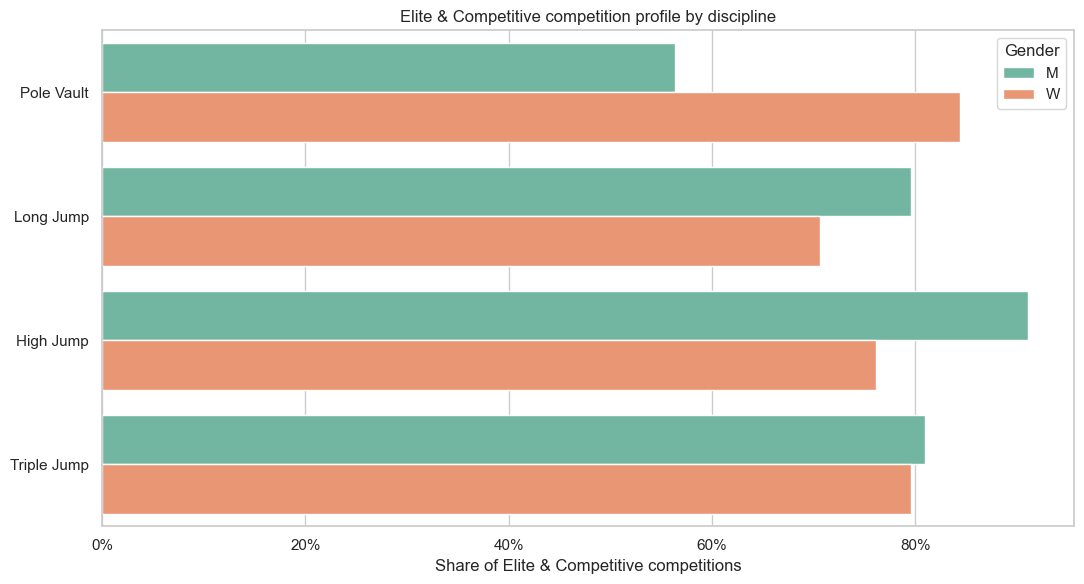

In [25]:
# Share of Elite & Competitive competitions
plot_data = (
    final_discipline_summary
    .sort_values("share_elite_competitive")
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=plot_data,
    x="share_elite_competitive",
    y="discipline",
    hue="gender",
    palette="Set2"
)

plt.gca().xaxis.set_major_formatter(
    plt.matplotlib.ticker.PercentFormatter(1.0)
)

plt.xlabel(
    "Share of Elite & Competitive competitions"
)

plt.ylabel("")

plt.title(
    "Elite & Competitive competition profile by discipline"
)

plt.legend(
    title="Gender"
)

plt.tight_layout()
plt.show()

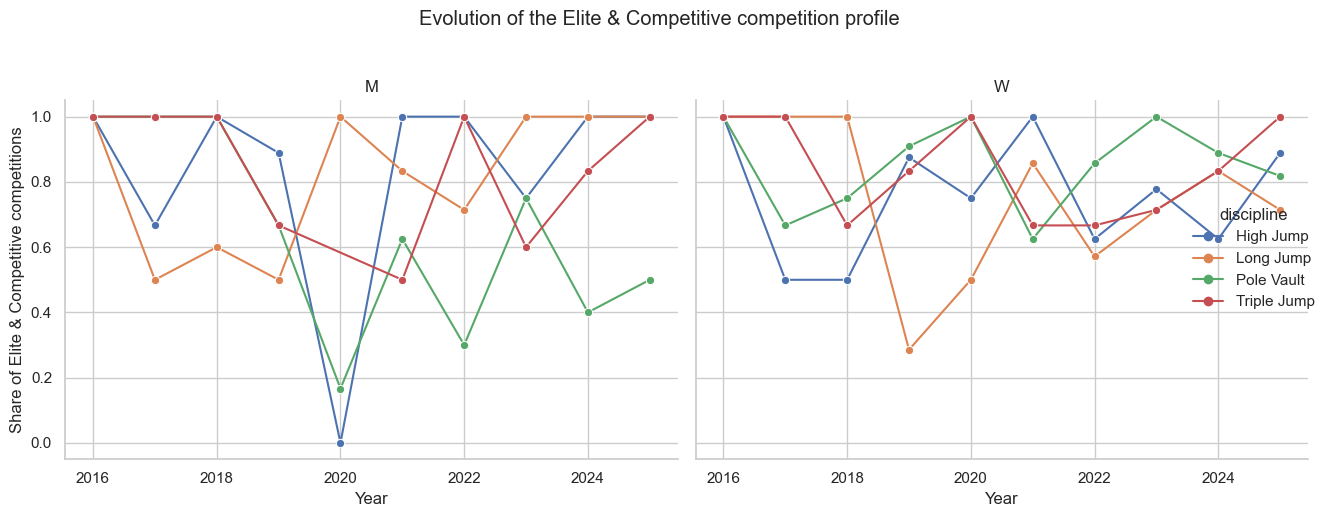

In [26]:
# Evolution of the target competition profile over time
yearly_elite_profile = (
    competition_scores
    .assign(
        elite_competitive=(
            competition_scores["segment"]
            == "Elite & Competitive"
        )
    )
    .groupby(
        ["year", "gender", "discipline"]
    )
    .agg(
        share_elite_competitive=(
            "elite_competitive",
            "mean"
        ),
        mean_world_level=(
            "world_level_score",
            "mean"
        ),
        mean_closeness=(
            "closeness_score",
            "mean"
        )
    )
    .reset_index()
)

g = sns.relplot(
    data=yearly_elite_profile,
    x="year",
    y="share_elite_competitive",
    hue="discipline",
    col="gender",
    kind="line",
    marker="o",
    height=5,
    aspect=1.2
)

g.set_axis_labels(
    "Year",
    "Share of Elite & Competitive competitions"
)

g.set_titles("{col_name}")

g.fig.suptitle(
    "Evolution of the Elite & Competitive competition profile",
    y=1.03
)

plt.tight_layout()
plt.show()

In [27]:
# Rank individual competitions by the two strategic dimensions
top_competitions = (
    competition_scores[
        competition_scores["segment"]
        == "Elite & Competitive"
    ]
    .copy()
)

top_competitions["strategic_score"] = (
    top_competitions["world_level_score"]
    + top_competitions["closeness_score"]
)

top_competitions = (
    top_competitions
    .sort_values(
        "strategic_score",
        ascending=False
    )
)

display(
    top_competitions[
        [
            "year",
            "competition_id",
            "gender",
            "discipline",
            "world_level_score",
            "closeness_score",
            "strategic_score",
            "segment"
        ]
    ].head(20)
)

,year,competition_id,gender,discipline,world_level_score,closeness_score,strategic_score,segment
105,2021,7132391,M,High Jump,1.169462,3.052296,4.221757,Elite & Competitive
260,2022,7153972,M,High Jump,1.354175,2.813534,4.167709,Elite & Competitive
433,2025,7203943,W,Pole Vault,1.428793,2.494053,3.922846,Elite & Competitive
41,2018,7120542,W,Pole Vault,1.317893,2.536210,3.854103,Elite & Competitive
31,2017,7104903,W,Long Jump,1.602013,2.194553,3.796565,Elite & Competitive
163,2023,7138987,W,Triple Jump,1.278853,2.380013,3.658866,Elite & Competitive
404,2025,7199686,M,Long Jump,1.878749,1.744150,3.622899,Elite & Competitive
74,2019,7130737,W,Pole Vault,0.918919,2.703048,3.621968,Elite & Competitive
220,2023,7147656,W,High Jump,1.331720,2.268010,3.599730,Elite & Competitive
69,2018,7121757,M,Pole Vault,1.368808,1.999652,3.368460,Elite & Competitive


In [28]:
# Final competition segment summary
final_segment_summary = (
    competition_scores
    .groupby("segment")
    .agg(
        n_competitions=("competition_id", "nunique"),
        mean_world_level=("world_level_score", "mean"),
        mean_closeness=("closeness_score", "mean")
    )
    .reset_index()
)

final_segment_summary["share"] = (
    final_segment_summary["n_competitions"]
    / final_segment_summary["n_competitions"].sum()
)

final_segment_summary = (
    final_segment_summary
    .sort_values(
        "mean_world_level",
        ascending=False
    )
)

display(
    final_segment_summary.round(3)
)

,segment,n_competitions,mean_world_level,mean_closeness,share
0,Elite & Competitive,107,0.206,0.820,0.591
1,Elite but Less Contested,72,-0.116,-2.635,0.398
2,Lower Level & Less Contested,2,-19.125,-1.536,0.011


# Final Business Conclusions

## 1. Competitive attractiveness

The most attractive competition profile is **Elite & Competitive**.

These competitions combine a strong international field with a high degree
of competitive closeness. They therefore represent the strongest
combination of sporting quality and competitive tension.

## 2. Discipline differences

The discipline-level ranking identifies where this profile is most
frequently observed.

The `share_elite_competitive` metric should be used as the primary KPI when
comparing disciplines because it directly measures the proportion of
competitions matching the target profile.

## 3. International strength is not enough

A high concentration of world-class athletes does not automatically imply
a highly competitive event.

Some competitions attract strong international fields but still produce
large gaps between the leading athletes.

This confirms the value of separating **World Level** from **Closeness**.

## 4. Competitive closeness is a distinct dimension

Some competitions are tightly contested even when their international field
is less prestigious.

These events may offer strong competitive tension without necessarily
having the highest concentration of world-ranked athletes.

## 5. Strategic target

For event selection, benchmarking or competition strategy, the strongest
target is therefore:

> **High World Level + High Competition Closeness**

The `Elite & Competitive` segment provides the operational definition of
this target profile.

## 6. Recommended KPI framework

The analysis can be summarized using three complementary KPIs:

| KPI | Business meaning |
|---|---|
| `World Level Score` | Strength of the international field |
| `Closeness Score` | Competitive tension between leading athletes |
| `Share of Elite & Competitive` | Frequency of the target competition profile |

Together, these indicators provide a more robust assessment of competition
quality than world ranking or performance gaps considered separately.